In [1]:
# Load libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor 
from sklearn.model_selection import train_test_split, GridSearchCV

In [2]:
df = pd.read_csv("C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 5 - Decision Tree/kc_house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
data = df.drop(['id', 'date', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_basement'], axis = 1)
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,yr_built,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,1955,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,1951,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,1933,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,1965,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,1987,1800,7503


In [4]:
data.isnull().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
yr_built         0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [5]:
x = data.drop('price', axis = 1)
y = data['price']

In [6]:
# Split dataset into training set and test set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42) 

In [7]:
# Create decision tree classifer object
dtr = DecisionTreeRegressor()
dtr.fit(x_train, y_train)

y_pred = dtr.predict(x_test)

print(dtr.get_params())

{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


In [8]:
print("R-Squared on train dataset = ", round(dtr.score(x_train, y_train), 2))
print("R-Squared on test dataset = ", round(dtr.score(x_test, y_test), 2))

R-Squared on train dataset =  1.0
R-Squared on test dataset =  0.51


In [9]:
df2 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df2.head()

,Actual,Predicted
735,365000.0,643000.0
2830,865000.0,722500.0
4106,1038000.0,975000.0
16218,1490000.0,1200000.0
19964,711000.0,415000.0


In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("Mean Squared Error: ", round(mean_squared_error(y_test, y_pred), 2))
print('Mean Absolute Error: ', round(mean_absolute_error(y_test, y_pred), 2))  
print('Root Mean Squared Error: ', round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))

Mean Squared Error:  74633281476.65
Mean Absolute Error:  161138.89
Root Mean Squared Error:  273190.92


**Important Features**

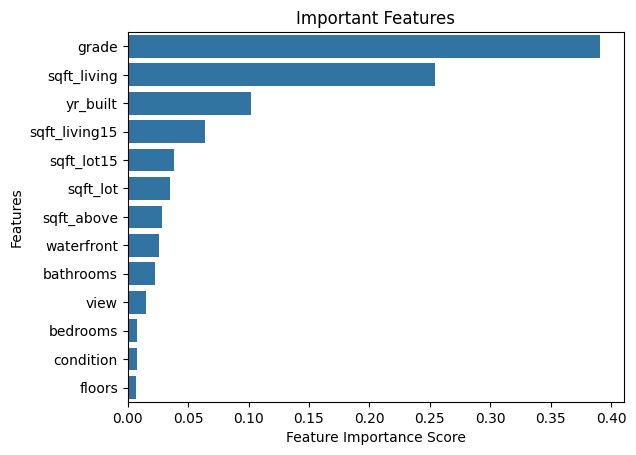

In [11]:
import matplotlib.pyplot as plt
feature_imp = pd.Series(dtr.feature_importances_, index = x_train.columns).sort_values(ascending = False)

# Creating a bar plot, displaying only the top k features
sns.barplot(x = feature_imp[:15], y = feature_imp.index[:15])
# Add labels to your graph
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Important Features")
plt.show()

**Grid Search CV**

In [12]:
from numpy import arange
dtr = DecisionTreeRegressor()

# Hyperparameter Optimization
parameters = {'max_features': ['log2', 'sqrt'], 
              'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
              'max_depth': arange(2, 10, 1), 
              'min_samples_split': arange(2, 20, 1),
              'min_samples_leaf': arange(1, 10, 1)
             }

# Run the grid search
grid_search_dtr = GridSearchCV(estimator = dtr, param_grid = parameters, scoring = 'r2', cv = 7)

grid_search_dtr.fit(x_train, y_train)
best_parameters_dtr = grid_search_dtr.best_params_  
best_score_dtr = grid_search_dtr.best_score_ 
print(best_parameters_dtr)
print(best_score_dtr)

best_model = grid_search_dtr.best_estimator_
y_pred_1 = best_model.predict(x_test)

print("Mean Squared Error: ", round(mean_squared_error(y_test, y_pred_1), 2))
print('Mean Absolute Error: ', round(mean_absolute_error(y_test, y_pred_1), 2))
print('Root Mean Squared Error: ', round(np.sqrt(mean_squared_error(y_test, y_pred_1)), 2))

{'criterion': 'poisson', 'max_depth': np.int64(9), 'max_features': 'sqrt', 'min_samples_leaf': np.int64(5), 'min_samples_split': np.int64(3)}
0.6581309585285187
Mean Squared Error:  53349829643.23
Mean Absolute Error:  142959.22
Root Mean Squared Error:  230975.82


In [13]:
df3 = pd.DataFrame({'Actual': y_test, 'Old Predicted': y_pred, 'New Predicted': y_pred_1.round(2)})
df3.head()

,Actual,Old Predicted,New Predicted
735,365000.0,643000.0,455430.40
2830,865000.0,722500.0,888656.25
4106,1038000.0,975000.0,1007227.59
16218,1490000.0,1200000.0,1446089.57
19964,711000.0,415000.0,602724.00
